<a href="https://colab.research.google.com/github/ramasamybenazir-deep/Python-DA-Assignment-2-Data-Visualization/blob/main/Python_Assign_2_%E2%80%93_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("taxis")

In [3]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [6]:
df['fare'] = df['fare'].fillna(df['fare'].median())

In [7]:
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])

In [8]:
df = df.dropna(subset=['pickup'])

In [9]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


In [10]:
import matplotlib.pyplot as plt

In [14]:
df['pickup'] = pd.to_datetime(df['pickup'])

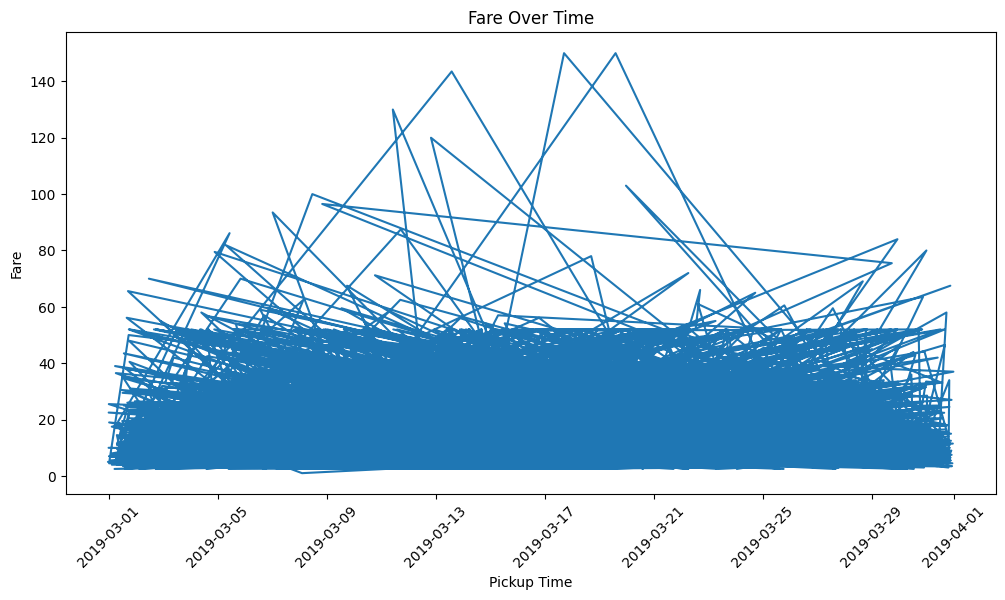

In [16]:

plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'])
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=45)
plt.show()


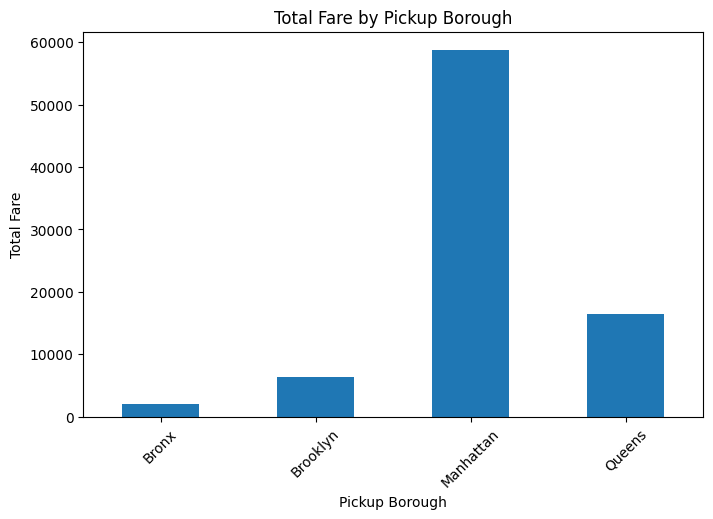

In [19]:
borough_fare = df.groupby('pickup_borough')['fare'].sum()
borough_fare.plot(kind='bar', figsize=(8, 5))
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

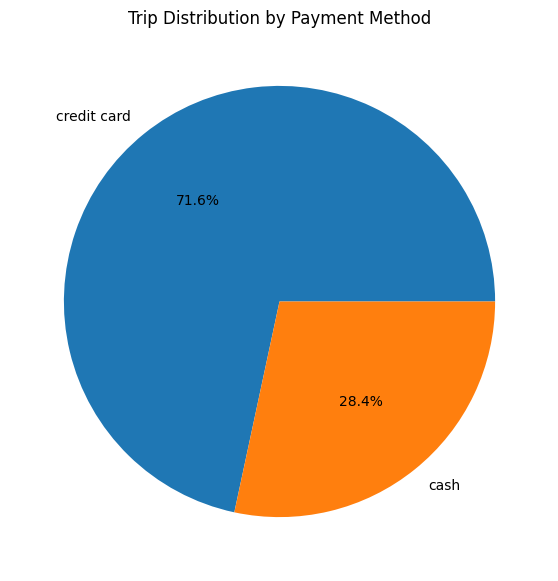

In [20]:
payment_counts = df['payment'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie( payment_counts, labels=payment_counts.index, autopct='%1.1f%%' )
plt.title('Trip Distribution by Payment Method')
plt.show()

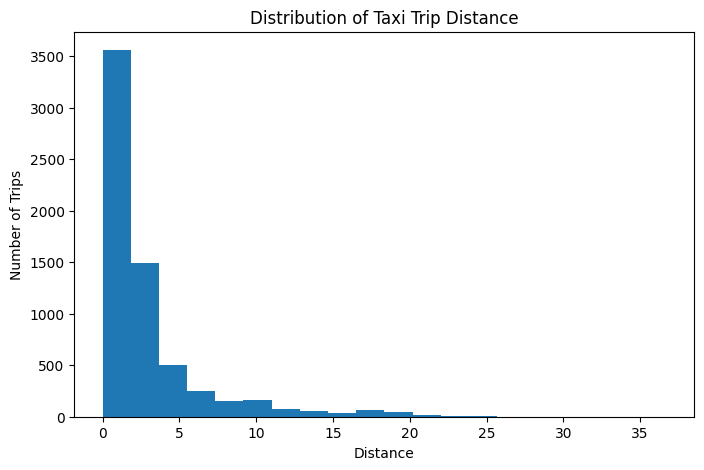

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=20)
plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Taxi Trip Distance')
plt.show()

<Figure size 1000x600 with 0 Axes>

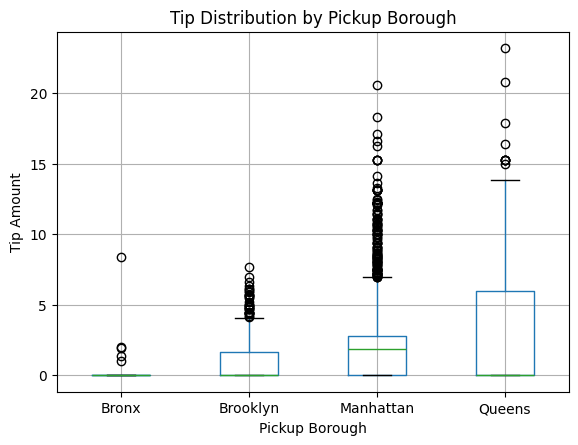

In [22]:
plt.figure(figsize=(10, 6))
df.boxplot( column='tip', by='pickup_borough' )
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.show()

In [24]:
#Seaborn Visualizations
# Count Plot – Trips by Pickup Borough

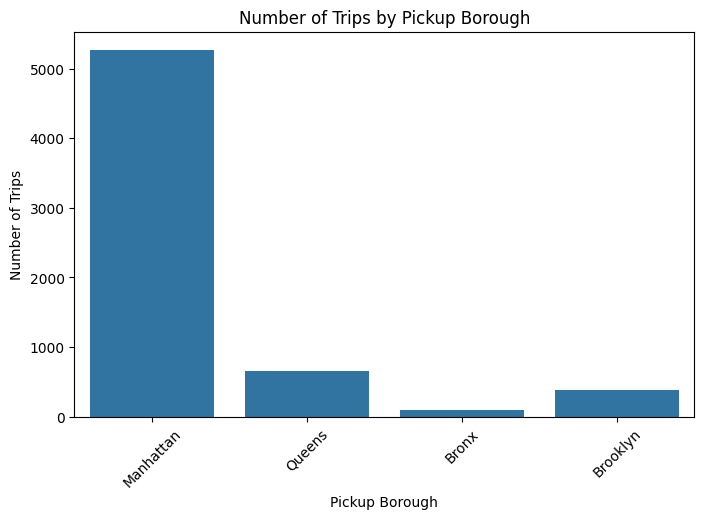

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot( data=df, x='pickup_borough' )
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

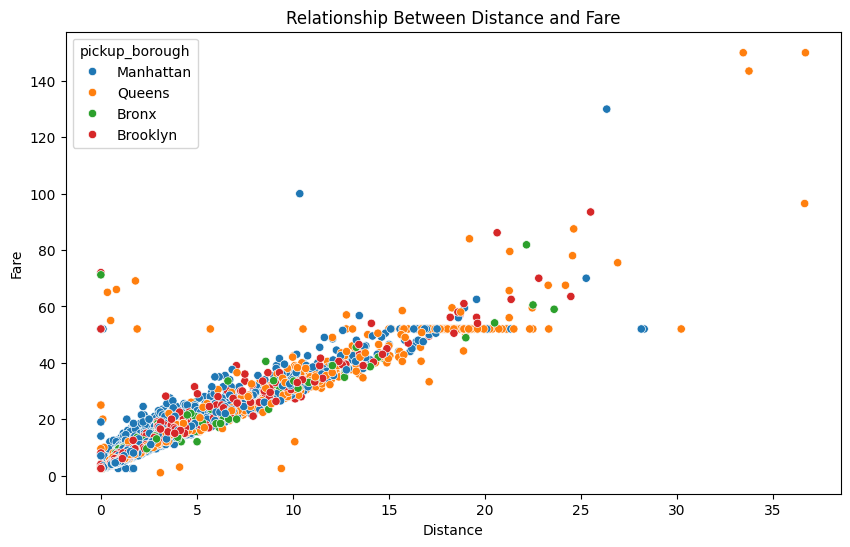

In [25]:
# Scatter Plot – Distance vs Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')

plt.show()

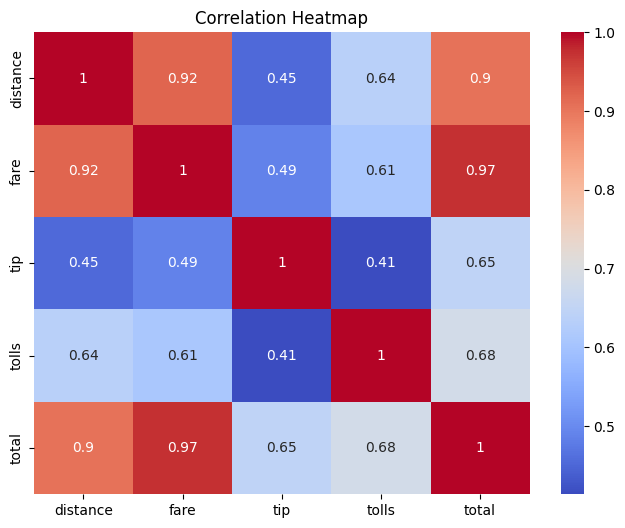

In [27]:
# Heatmap – Correlation Matrix



correlation = df[
    ['distance', 'fare', 'tip', 'tolls', 'total']
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

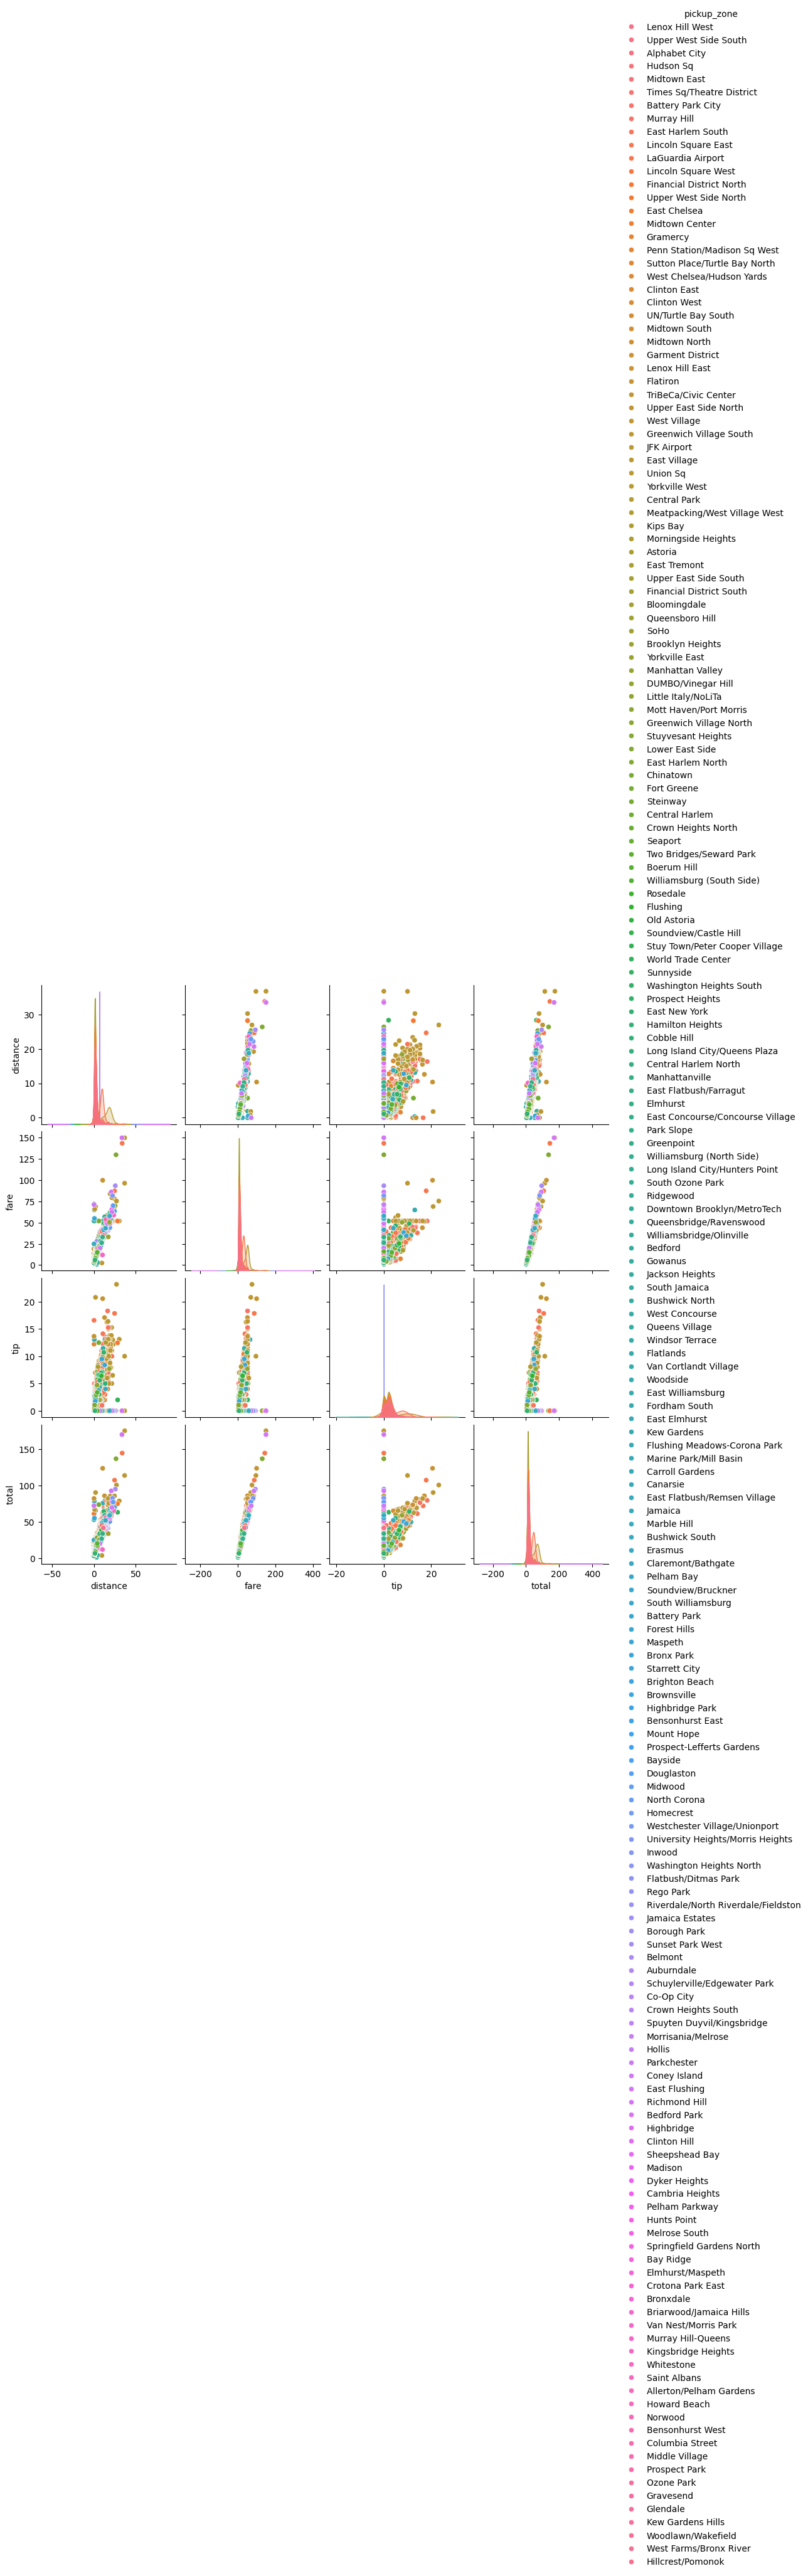

In [29]:
# Pair Plot – Numerical Variable Relationships
sns.pairplot(
    df[
        ['distance', 'fare', 'tip', 'total', 'pickup_zone']
    ].dropna(),
    hue='pickup_zone'
)

plt.show()


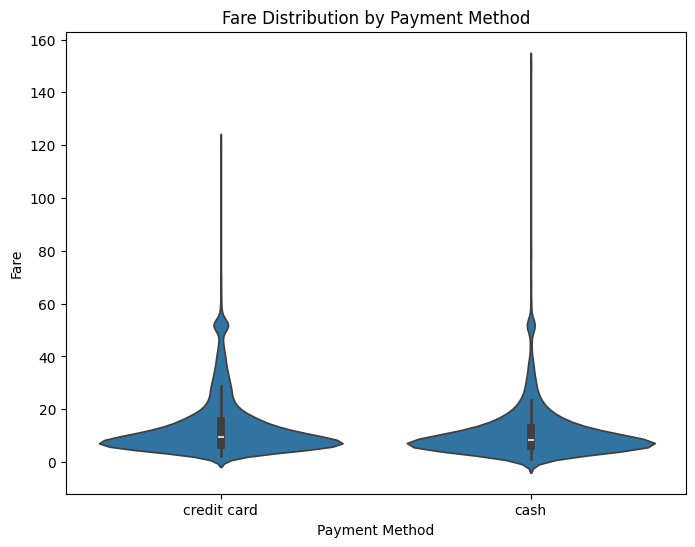

In [30]:
#Violin Plot – Fare by Payment Method
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')

plt.show()